In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("Mall_Customers.csv")


In [ ]:
print(df.head())

print(df.info())

print(df.columns)

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
Index(['CustomerID', 'Genre', 'Age', 'Annual Income

In [ ]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])

print(df.head())

   CustomerID  Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1      1   19                  15                      39
1           2      1   21                  15                      81
2           3      0   20                  16                       6
3           4      0   23                  16                      77
4           5      0   31                  17                      40


In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

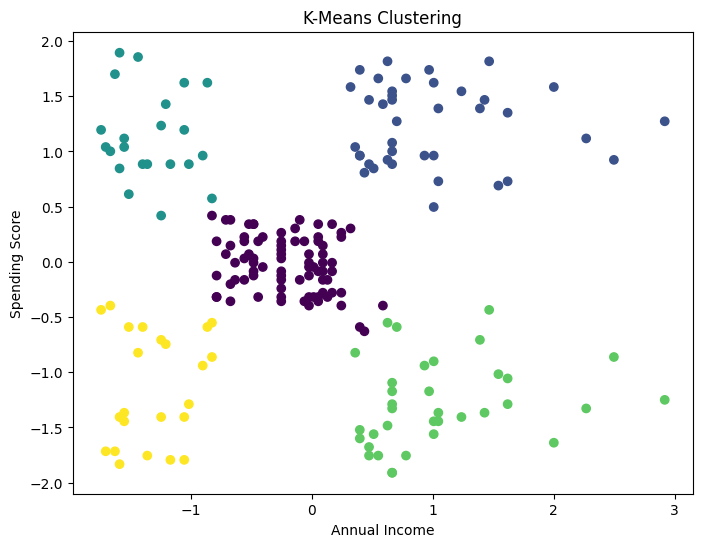

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=kmeans_labels
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")

plt.show()

In [ ]:
kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print(
    "K-Means Silhouette Score:",
    kmeans_score
)

K-Means Silhouette Score: 0.5546571631111091


In [ ]:
print(type(X_scaled))
print(X_scaled.shape)

<class 'numpy.ndarray'>
(200, 2)


In [ ]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=5)

agg_labels = agg.fit_predict(X_scaled)

print(agg_labels)

[4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4
 3 4 3 4 3 4 2 4 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 2 1 0 1 2 1
 0 1 0 1 0 1 0 1 0 1 0 1 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]


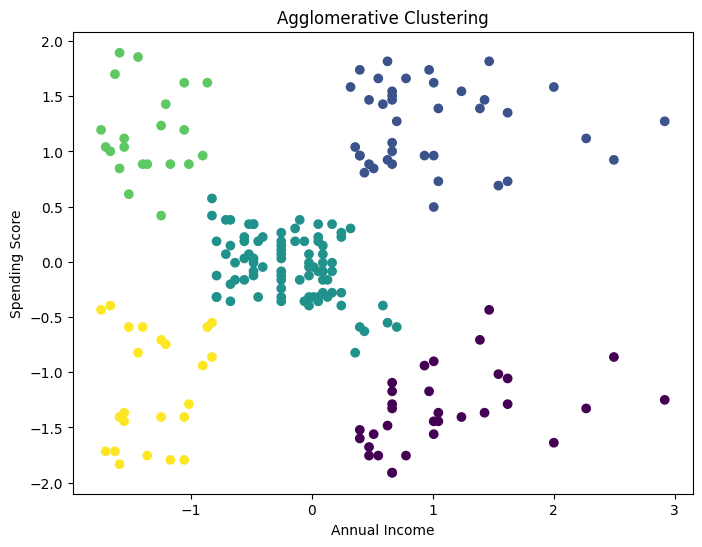

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=agg_labels
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Agglomerative Clustering")

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

agg_score = silhouette_score(
    X_scaled,
    agg_labels
)

print(
    "Agglomerative Silhouette Score:",
    agg_score
)

Agglomerative Silhouette Score: 0.5538089226688662


In [ ]:
print("K-Means Silhouette Score:", kmeans_score)

print(
    "Agglomerative Silhouette Score:",
    agg_score
)

K-Means Silhouette Score: 0.5546571631111091
Agglomerative Silhouette Score: 0.5538089226688662


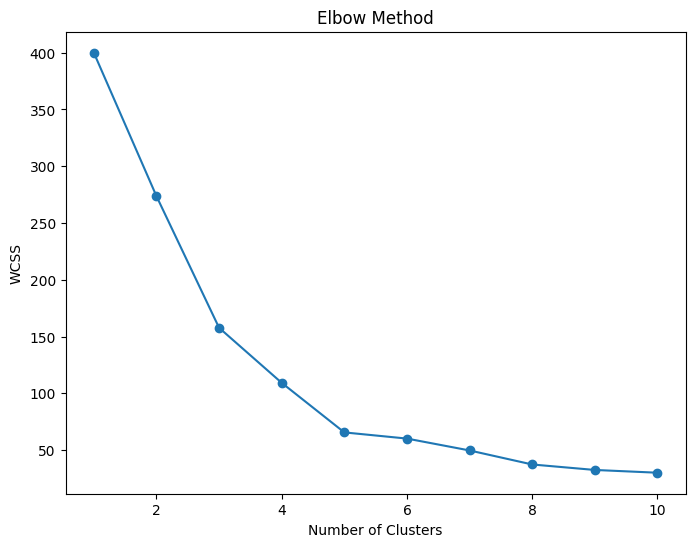

In [ ]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(
        km.inertia_
    )

plt.figure(figsize=(8,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel(
    "Number of Clusters"
)

plt.ylabel("WCSS")

plt.title(
    "Elbow Method"
)

plt.show()